# 0 - Machine Learning de Lenguaje Supervisado

Ahora que tenemos los conceptos generales de Machine Learning y hemos visto cómo representar el lenguaje en formato numérico, estamos en capacidad de poder ver cómo podemos aplicar los conceptos de Machine Learning a problemas de lenguaje

<br>

### Caso real: Grammarly

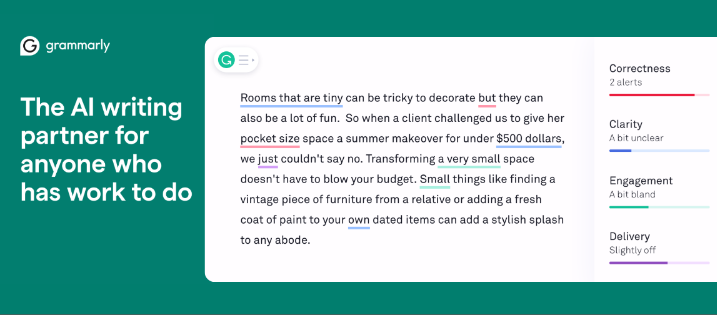

Con el boom de internet, redes sociales, digitalización de contenidos en la década de los 2000-2010 vimos un gran aumento de la creación de contenido digital, especialmente escrito. Ya no solo era importante buscarlo, también era importante clasificarlo, detectar keywords, corregirlos... Nuevos productos como gramarlly usaron para ello técnicas de IA

<br>

# 1 - Clasificación de texto

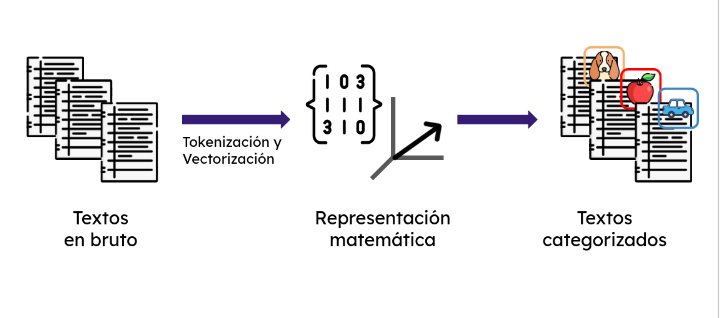

La clasificación de texto, al igual que cualquier algoritmo de clasificación de ML, tiene como objetivo clasificar un dato de entrada en una categoría. En el caso del lenguaje es común querer clasificar texto en base a una categoría (por ejemplo, su temática).

**Ejercicio**: ¿Qué ejemplos de casos de uso de machine learning supervisado y clasificadores se os ocurren a vosotros?

## 1.1 - Corpus etiquetado

###  Fake News Dataset

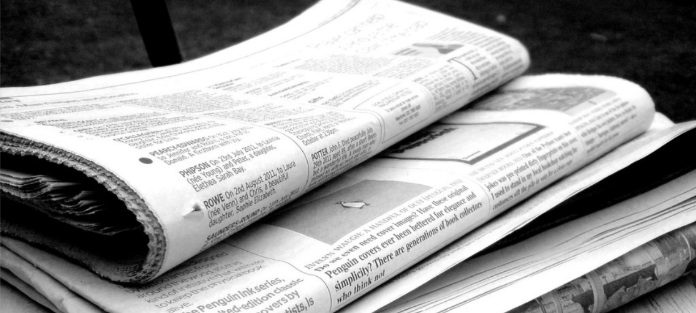

Un uso muy común del uso del NLP a día de hoy es el de poder monitorizar fuentes escritas de internet como puede ser blogs, redes sociales o prensa escrita. Un problema muy común durante estos últimos años la detección automática de noticias falsas.

Fake news dataset es un corpus que contiene diferentes registros de textos de prensa escrita en español sobre diferentes noticias. Estos textos están etiquetados tanto con la temática de la noticia como con si la noticia es o no fake

In [28]:
import pandas as pd

df = pd.read_csv("hf://datasets/mariagrandury/fake_news_corpus_spanish/test.csv")

df = df.drop('ID', axis=1)

df

,CATEGORY,TOPICS,SOURCE,HEADLINE,TEXT,LINK
0,True,Covid-19,El Economista,Covid-19: mentiras que matan,El control de la Covid-19 no es sólo un tema d...,https://www.eleconomista.com.mx/opinion/Covid-...
1,False,Política,El matinal,El Gobierno podrá acceder a las IPs de los móv...,El Gobierno de Pedro Sánchez y Pablo Iglesias ...,https://www.elmatinal.com/espana-ultima-hora/e...
2,True,Política,El País,La comunidad musulmana catalana denuncia a Vox...,Las tres federaciones que agrupan al 90% de la...,https://elpais.com/espana/elecciones-catalanas...
3,False,Política,AFPFactual,NaN,Se han dado a conocer los datos electorales pr...,https://perma.cc/GYE6-SPMB
4,True,Sociedad,La Republica,El censo poblacional 2018 tendrá un costo de $...,La primera fase del censo será virtual y solo ...,https://www.larepublica.co/economia/el-censo-p...
...,...,...,...,...,...,...
567,True,Covid-19,El Financiero,Encuentran nueva variante de COVID en México: ...,El Instituto de Diagnóstico y Referencia Epide...,https://www.elfinanciero.com.mx/salud/encuentr...
568,False,Sociedad,diariogol,El móvil de más de 60.000 euros de la princesa...,La hija del rey Felipe y de la reina Letizia y...,https://www.diariogol.com/gossip/el-movil-de-m...
569,False,Política,AFPFactual,NaN,"Evidentemente, Barak Obama ha sido arrestado e...","Perma | Obama, Biden y la directora de la CIA,..."
570,True,Covid-19,Redacción Médica,Covid: las vacunas puestas en España no alcanz...,El Ministerio de Sanidad ha actualizado los da...,https://www.redaccionmedica.com/secciones/sani...


<br>

## 1.2 - Preparación del dataset

### Vocabulario

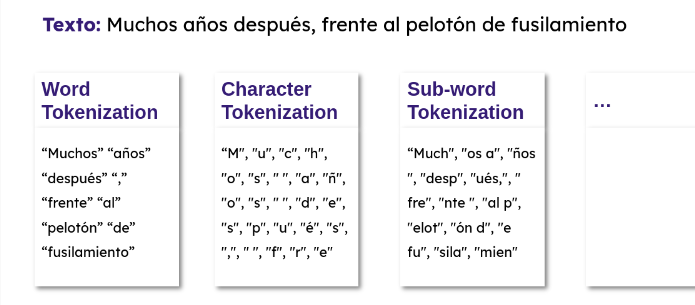

**Ejercicio** - ¿Para qué servía el vocabulario?

* ¿Qué formas teníamos de crear un vocabulario?

* ¿Qué formas tenemos de definir una tokenización?

* ¿Cual de las dos formas es mejor en este caso?

<br>

### Vectorización de texto

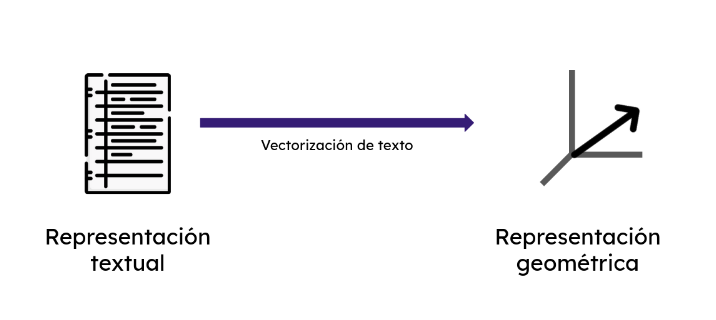

Como hemos visto en sesiones anteriores, antes de poder aplicar un modelo de ML sobre texto, es necesario convertir el texto a una representación numéricas. La forma más común de representar documentos de manera semántica en el machine learning tradicional (en el capítulo del deep learning veremos que hay más formas) es usando la vectorización de TF-idf.

In [29]:
import nltk
import requests

nltk.download('stopwords')

from sklearn.feature_extraction.text import TfidfVectorizer


corpus = df.TEXT.to_list()

vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer='word',
    stop_words= nltk.corpus.stopwords.words('spanish'),
    ngram_range=(1, 3),
    min_df=0.01,
    max_df=0.80,
    max_features=1200,
).fit(corpus)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/thinbaker/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**N-gramas generados**

In [47]:
print(vectorizer.get_feature_names_out().tolist())

['000', '000 habitantes', '000 millones', '000 personas', '10', '100', '100 000', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '200', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '21', '22', '24', '25', '28', '30', '40', '50', '500', '5g', '60', '70', '80', '90', 'aborto', 'abril', 'acceso', 'acciones', 'acción', 'acerca', 'actividad', 'actividades', 'acto', 'actual', 'actualmente', 'acuerdo', 'además', 'administración', 'adultos', 'afectados', 'afirma', 'afirmó', 'agencia', 'agentes', 'agosto', 'agregó', 'agua', 'ahora', 'ahí', 'aire', 'alerta', 'alguien', 'alguna', 'algún', 'alimentos', 'allá', 'allí', 'alrededor', 'alta', 'alto', 'altos', 'ambas', 'ambiente', 'ambos', 'amenaza', 'amigos', 'amor', 'américa', 'américa latina', 'ancianos', 'andalucía', 'andrés', 'animales', 'anterior', 'anticuerpos', 'anuncio', 'anunció', 'análisis', 'apenas', 'aplicación', 'apoyo', 'aproximadamente', 'aquellos', 'aquí', 'argentina', 'arn', 'arnm', 'asegura', 'aseguró'

**Vectores de los textos**

In [31]:
corpus_vectorized = vectorizer.transform(corpus)
corpus_vectorized.todense()[0:10]

matrix([[0.        , 0.        , 0.        , ..., 0.09744331, 0.        ,
         0.05385778],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.06854571, 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.20894542, 0.07656345, 0.        , ..., 0.05346707, 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.0666369 ,
         0.        ]], shape=(10, 1200))

In [32]:
pd.DataFrame(corpus_vectorized)

,0
0,<Compressed Sparse Row sparse matrix of dtype ...
1,<Compressed Sparse Row sparse matrix of dtype ...
2,<Compressed Sparse Row sparse matrix of dtype ...
3,<Compressed Sparse Row sparse matrix of dtype ...
4,<Compressed Sparse Row sparse matrix of dtype ...
...,...
567,<Compressed Sparse Row sparse matrix of dtype ...
568,<Compressed Sparse Row sparse matrix of dtype ...
569,<Compressed Sparse Row sparse matrix of dtype ...
570,<Compressed Sparse Row sparse matrix of dtype ...


<br>

### Reducción de dimensionalidad

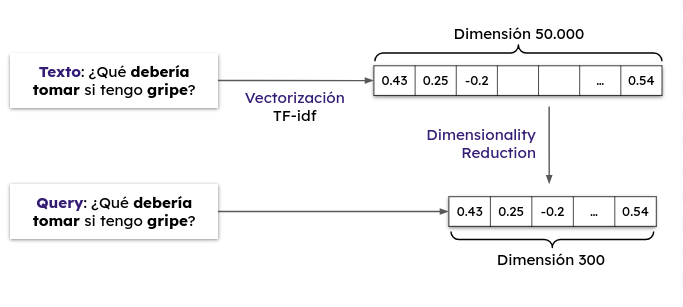

Aunque ya con la vectorización podríamos aplicar un algoritmo de ML, es cierto que la vectorización TFidf tiene una dimensión muy alta (1200) y podría dificultar el proceso de aprendizaje. Por ello es recomendable usar un algorimto de reducción de dimensionalidad

In [33]:
from sklearn.decomposition import TruncatedSVD

dim_reducer = TruncatedSVD(
    n_components=200,
    random_state=42,
).fit(corpus_vectorized)

corpus_vectorized_reduced = dim_reducer.transform(corpus_vectorized)
corpus_vectorized_reduced

array([[ 0.37983001,  0.0091901 ,  0.09810738, ..., -0.01021609,
         0.01243288,  0.04205207],
       [ 0.2269826 , -0.20063324,  0.07166841, ...,  0.01907284,
         0.00211359,  0.02579234],
       [ 0.21044753, -0.19246222,  0.04141662, ...,  0.01505023,
        -0.02717748,  0.00876597],
       ...,
       [ 0.22796283, -0.17591359,  0.12606516, ...,  0.01697451,
         0.01569275, -0.02234624],
       [ 0.25268432,  0.09178377,  0.33708798, ..., -0.03296435,
        -0.02525249,  0.02353605],
       [ 0.33770665,  0.12804181, -0.16480904, ..., -0.01681312,
        -0.04097196,  0.02437804]], shape=(572, 200))

In [34]:
pd.DataFrame(corpus_vectorized_reduced)

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.379830,0.009190,0.098107,-0.019172,0.014370,-0.149232,-0.022169,-0.092974,0.077393,-0.012082,...,-0.043281,0.015403,0.064469,0.044269,0.036734,0.049306,-0.003507,-0.010216,0.012433,0.042052
1,0.226983,-0.200633,0.071668,-0.107105,-0.219740,0.048708,-0.056118,0.118562,0.014744,-0.016900,...,0.029396,-0.001517,0.056193,0.017967,0.047683,0.030992,0.047885,0.019073,0.002114,0.025792
2,0.210448,-0.192462,0.041417,-0.000904,-0.037386,0.016232,0.003880,0.123397,-0.062689,-0.016521,...,0.047596,0.007120,0.022761,0.022867,0.084999,0.007248,-0.074772,0.015050,-0.027177,0.008766
3,0.180911,-0.078203,0.054060,-0.064261,0.057176,-0.051216,-0.024158,0.068630,0.031620,0.062387,...,0.012468,0.052353,-0.034830,0.014095,-0.087536,0.008578,-0.022670,0.085152,-0.036942,0.013780
4,0.241500,-0.071912,0.074438,-0.016359,-0.025143,0.002765,-0.009058,-0.116712,-0.012530,0.005106,...,-0.066644,-0.019113,0.053638,-0.077597,-0.080360,0.009759,-0.021584,-0.037591,0.098337,0.042588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,0.163476,0.017567,0.003037,-0.057535,-0.034304,-0.032312,0.068640,-0.038545,0.037062,0.029875,...,0.008295,0.037559,0.000898,0.021268,0.006920,0.009321,0.031451,-0.005249,0.007438,-0.016727
568,0.243172,-0.136978,-0.017598,-0.015545,-0.125163,0.085712,-0.047758,0.049334,-0.086768,-0.020561,...,0.065450,-0.033338,-0.042299,-0.076986,-0.011951,0.021649,-0.062634,0.029313,0.042500,-0.053623
569,0.227963,-0.175914,0.126065,-0.248409,0.411234,-0.068508,0.013991,0.150601,-0.165173,0.128685,...,-0.002017,0.010783,0.029738,-0.003269,0.052564,0.017588,-0.000536,0.016975,0.015693,-0.022346
570,0.252684,0.091784,0.337088,0.051575,-0.163253,-0.003276,0.003898,-0.034962,-0.148934,0.005414,...,-0.021062,0.050866,-0.066853,-0.035820,0.003909,-0.059703,-0.020978,-0.032964,-0.025252,0.023536


<br>

### Base de conocimiento

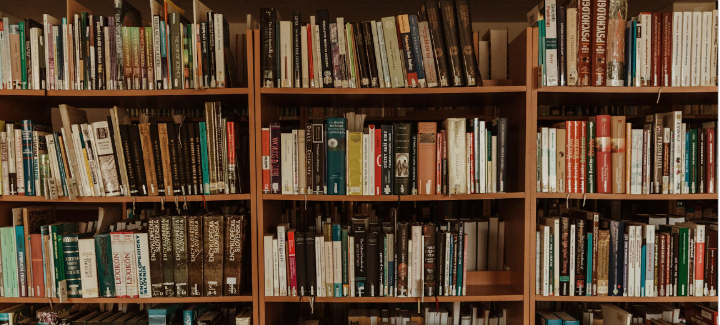

In [35]:
vectors = pd.DataFrame(corpus_vectorized_reduced)

database = df[['TEXT']].join(vectors)

database

,TEXT,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
0,El control de la Covid-19 no es sólo un tema d...,0.379830,0.009190,0.098107,-0.019172,0.014370,-0.149232,-0.022169,-0.092974,0.077393,...,-0.043281,0.015403,0.064469,0.044269,0.036734,0.049306,-0.003507,-0.010216,0.012433,0.042052
1,El Gobierno de Pedro Sánchez y Pablo Iglesias ...,0.226983,-0.200633,0.071668,-0.107105,-0.219740,0.048708,-0.056118,0.118562,0.014744,...,0.029396,-0.001517,0.056193,0.017967,0.047683,0.030992,0.047885,0.019073,0.002114,0.025792
2,Las tres federaciones que agrupan al 90% de la...,0.210448,-0.192462,0.041417,-0.000904,-0.037386,0.016232,0.003880,0.123397,-0.062689,...,0.047596,0.007120,0.022761,0.022867,0.084999,0.007248,-0.074772,0.015050,-0.027177,0.008766
3,Se han dado a conocer los datos electorales pr...,0.180911,-0.078203,0.054060,-0.064261,0.057176,-0.051216,-0.024158,0.068630,0.031620,...,0.012468,0.052353,-0.034830,0.014095,-0.087536,0.008578,-0.022670,0.085152,-0.036942,0.013780
4,La primera fase del censo será virtual y solo ...,0.241500,-0.071912,0.074438,-0.016359,-0.025143,0.002765,-0.009058,-0.116712,-0.012530,...,-0.066644,-0.019113,0.053638,-0.077597,-0.080360,0.009759,-0.021584,-0.037591,0.098337,0.042588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,El Instituto de Diagnóstico y Referencia Epide...,0.163476,0.017567,0.003037,-0.057535,-0.034304,-0.032312,0.068640,-0.038545,0.037062,...,0.008295,0.037559,0.000898,0.021268,0.006920,0.009321,0.031451,-0.005249,0.007438,-0.016727
568,La hija del rey Felipe y de la reina Letizia y...,0.243172,-0.136978,-0.017598,-0.015545,-0.125163,0.085712,-0.047758,0.049334,-0.086768,...,0.065450,-0.033338,-0.042299,-0.076986,-0.011951,0.021649,-0.062634,0.029313,0.042500,-0.053623
569,"Evidentemente, Barak Obama ha sido arrestado e...",0.227963,-0.175914,0.126065,-0.248409,0.411234,-0.068508,0.013991,0.150601,-0.165173,...,-0.002017,0.010783,0.029738,-0.003269,0.052564,0.017588,-0.000536,0.016975,0.015693,-0.022346
570,El Ministerio de Sanidad ha actualizado los da...,0.252684,0.091784,0.337088,0.051575,-0.163253,-0.003276,0.003898,-0.034962,-0.148934,...,-0.021062,0.050866,-0.066853,-0.035820,0.003909,-0.059703,-0.020978,-0.032964,-0.025252,0.023536


<br>

## 1.3 - Modelo de clasificación

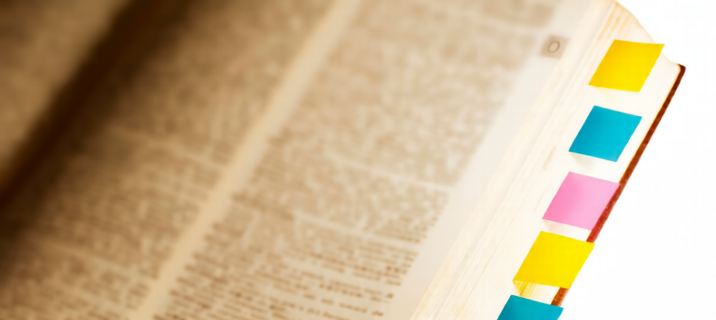

Finalmente creamos un algoritmo de clasificación que aprenda, en base a la representación numérica de los documentos, a predecir si una noticia es fake o no

**Features**

In [36]:
X = database.drop(['TEXT'], axis=1)

X

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.379830,0.009190,0.098107,-0.019172,0.014370,-0.149232,-0.022169,-0.092974,0.077393,-0.012082,...,-0.043281,0.015403,0.064469,0.044269,0.036734,0.049306,-0.003507,-0.010216,0.012433,0.042052
1,0.226983,-0.200633,0.071668,-0.107105,-0.219740,0.048708,-0.056118,0.118562,0.014744,-0.016900,...,0.029396,-0.001517,0.056193,0.017967,0.047683,0.030992,0.047885,0.019073,0.002114,0.025792
2,0.210448,-0.192462,0.041417,-0.000904,-0.037386,0.016232,0.003880,0.123397,-0.062689,-0.016521,...,0.047596,0.007120,0.022761,0.022867,0.084999,0.007248,-0.074772,0.015050,-0.027177,0.008766
3,0.180911,-0.078203,0.054060,-0.064261,0.057176,-0.051216,-0.024158,0.068630,0.031620,0.062387,...,0.012468,0.052353,-0.034830,0.014095,-0.087536,0.008578,-0.022670,0.085152,-0.036942,0.013780
4,0.241500,-0.071912,0.074438,-0.016359,-0.025143,0.002765,-0.009058,-0.116712,-0.012530,0.005106,...,-0.066644,-0.019113,0.053638,-0.077597,-0.080360,0.009759,-0.021584,-0.037591,0.098337,0.042588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,0.163476,0.017567,0.003037,-0.057535,-0.034304,-0.032312,0.068640,-0.038545,0.037062,0.029875,...,0.008295,0.037559,0.000898,0.021268,0.006920,0.009321,0.031451,-0.005249,0.007438,-0.016727
568,0.243172,-0.136978,-0.017598,-0.015545,-0.125163,0.085712,-0.047758,0.049334,-0.086768,-0.020561,...,0.065450,-0.033338,-0.042299,-0.076986,-0.011951,0.021649,-0.062634,0.029313,0.042500,-0.053623
569,0.227963,-0.175914,0.126065,-0.248409,0.411234,-0.068508,0.013991,0.150601,-0.165173,0.128685,...,-0.002017,0.010783,0.029738,-0.003269,0.052564,0.017588,-0.000536,0.016975,0.015693,-0.022346
570,0.252684,0.091784,0.337088,0.051575,-0.163253,-0.003276,0.003898,-0.034962,-0.148934,0.005414,...,-0.021062,0.050866,-0.066853,-0.035820,0.003909,-0.059703,-0.020978,-0.032964,-0.025252,0.023536


**Labels**

In [37]:
y, unique_categories = pd.factorize(df['TOPICS'])

id2category = {}
for id, category_name in enumerate(unique_categories):
    id2category[id] = category_name

print(id2category)
print(y[0:20])

{0: 'Covid-19', 1: 'Política', 2: 'Sociedad', 3: 'Internacional', 4: 'Ciencia', 5: 'Deporte', 6: 'Ambiental'}
[0 1 1 1 2 0 1 0 0 0 2 0 1 0 0 2 2 0 2 1]


<br>

### Entrenamiento

Podemos usar cualquiera de los algoritmos que conocemos de clasificación: Random Forest, KNN, Decision Trees,... Nosotros vamos a usar el Support Vector Machine Classifier (SVC)

In [38]:
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split

# Separamos entre conjunto de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, shuffle=True, stratify=y)

# Entrenamos el modelo
clf = SVC().fit(X_train, y_train)

>**Nota**: El algoritmo de SVC es un algoritmo usado recurrentemente para la clasificación de textos usando vectores.

<br>

### Evaluación

In [39]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluamos sobre el grupo de test
y_pred=clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.92      0.81        48
           1       0.64      0.33      0.44        21
           2       0.68      0.77      0.72        39
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         1

    accuracy                           0.70       115
   macro avg       0.34      0.34      0.33       115
weighted avg       0.65      0.70      0.67       115



/home/thinbaker/Workspace/Curso-de-IA-y-NLP/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/thinbaker/Workspace/Curso-de-IA-y-NLP/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/thinbaker/Workspace/Curso-de-IA-y-NLP/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Aquí solo estamos usando el algoritmo de SVC como modelo de clasificación (debido a que es uno de los más comúnes para hacer clasificación de texto junto con TF-idf) sin embargo, llegados a este punto podríamos usar cualquier algoritmo de clasificación visto en sesiones anteriores

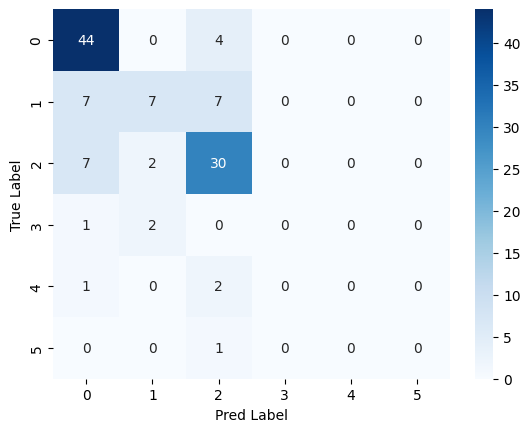

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Pred Label')

plt.ylabel('True Label')

plt.show()

<br>

### Predicción

In [ ]:
text = "El Gobierno acusado por un nuevo caso de corrupción"

# Aplicamos el modelo de vectorización ya entrenado
text_vectorized = vectorizer.transform([text])

# Aplicamos la reducción de dimensionalidad
text_vectorized_reduced = dim_reducer.transform(text_vectorized)

# Predecimos la categoría
prediction = clf.predict(text_vectorized_reduced)

print(text)
print(id2category[prediction[0]])

El Gobierno acusado por un nuevo caso de corrupción
Política


<br>

---

# 2 - Clasificación de tokens

Además de poder clasificar texto, también podemos clasificar palabras dentro de un texto, dos aplicaciones comunes de este tipo de clasificación son los siguientes:

**Named Entity Recognition (NER)**

Este tipo de problemas buscan detectar "entidades" dentro del texto asociadas a una categoría. Algunos ejemplos de categorías comunes en los clasificadores de NER suelen ser: personas, empresas, ciudades,... Este tipo de algoritmos se suelen usar para detectar cuando se habla de una determinada persona en algún documento.

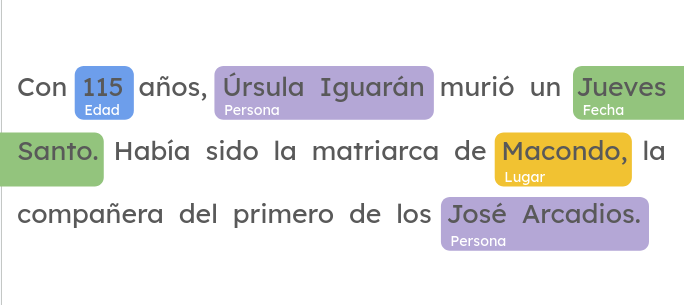

**Part Of Speech (POS)**

Este tipo de modelos sirven para detectar la función sintáctica de cada una de las palabras en la frase. Este tipo de algoritmos se usan para detectar las dependiencias sintácticas entre palabras, y oraciones, de manera que se pueda hacer cosas como "grafos de conocimiento" que permiten representar las relaciones entre ideas de un texto

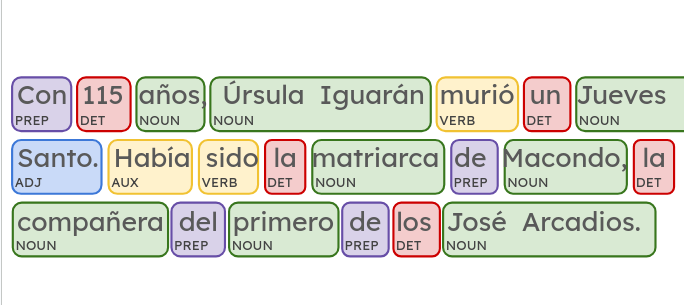

## 2.1 - Corpus etiquetado

### Podcast NER

Este conjunto de datos está compuesto por pequeños fragmentos de texto extraídos del pódcast "Deforme Semanal", acompañados de anotaciones que identifican la presencia de un conjunto predeterminado de entidades. El propósito de este conjunto de datos es facilitar las tareas de Reconocimiento de Entidades Nombradas (NER). Fue creado para ayudar en la identificación de entidades como personas famosas, libros o películas en pódcasts. Primero se transcribió el audio, luego se realizaron anotaciones con GPT-3 y una curación con Argilla. El conjunto de datos está en español y abarca principalmente temas como el amor, el feminismo y el arte, que son los temas centrales del pódcast.

In [50]:
import pandas as pd

splits = {'train': 'data/train-00000-of-00001-ac966cb4770ad145.parquet', 'test': 'data/test-00000-of-00001-d6a836df2a000de9.parquet'}
df = pd.read_parquet("hf://datasets/somosnlp-hackathon-2023/podcasts-ner-es/" + splits["train"])
df

,id,text,annotation
0,53c4748e-dbd2-4cf5-946f-d134b0bf6155,"Tengo 39 años, pues, ya veré cuándo yo quiero ...","[{'end': 13, 'label': 'DATES', 'start': 6}]"
1,0d6783a0-f249-43fe-b845-88db7e4c7f10,"Cuando sales de casa, ya estás planeando que f...","[{'end': 67, 'label': 'ORGANIZATIONS', 'start'..."
2,44a3e10b-42af-477c-9b72-eca95ca01f14,"Lo es la amante de Catherine, Roxy y con un pa...","[{'end': 28, 'label': 'PEOPLE', 'start': 19}, ..."
3,74f767fc-b14e-4844-8a30-6d882d48c162,¿Cómo hacer para que pese a entender que la id...,"[{'end': 67, 'label': 'TOPIC', 'start': 53}]"
4,0771a9fb-4f9a-4aa4-aae6-cc0c0c5692a6,Lo descubrirás cuando te vayas a vivir con él ...,"[{'end': 64, 'label': 'DATES', 'start': 52}, {..."
...,...,...,...
204,7dbff663-b712-4138-b359-7359f694c0e7,¿Qué nos importa la pequeñita sabana de la cam...,"[{'end': 178, 'label': 'PLACES', 'start': 175}..."
205,bd84fe26-ffdb-49e1-90bd-9b6bcb35b44b,¿Cómo vas a ser egoísta por querer un amor?,"[{'end': 42, 'label': 'TOPIC', 'start': 38}]"
206,170e94d6-2eb3-44f7-b499-ff031720a1bd,Ahora la gente lo dice como que es original.,"[{'end': 43, 'label': 'TOPIC', 'start': 35}]"
207,51a974cf-810e-44ed-aa70-c8ecb7e183a9,"Era nazi Heidegger, y fue su amor.","[{'end': 18, 'label': 'PEOPLE', 'start': 9}, {..."


<br>

## 2.2 - Preparación del dataset

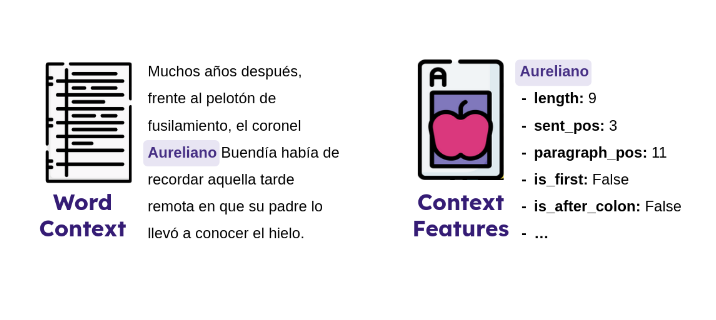

### Modelado del corpus

Para poder usar correctamente el corpus necesitamos formatearlo de manera que cada palabra de cada frase tenga su etiqueta

In [51]:
import re

corpus = [{'text': row['text'], 'labels': row['annotation']} for _,row in df.iterrows()]

def process_corpus(corpus):

    new_corpus = []
    for row in corpus:
        current_pos = 0
        words = []
        for label in row['labels']:
            words.append([row['text'][current_pos: label['start']],''])
            words.append([row['text'][label['start']:label['end']],label['label']])
            current_pos = label['end']

        words.append([row['text'][current_pos:],''])

        for i in range(len(words)):
            if words[i][1]=='':
                sentence = re.findall( r'\w+|[^\s\w]+', words[i][0])
                words[i] = [[word,''] for word in sentence]
            else:
                words[i] = [words[i]]

        words = [item for row in words for item in row]

        new_corpus.append(words)
    return new_corpus

corpus = process_corpus(corpus)
corpus[0:2]

[[['Tengo', ''],
  ['39 años', 'DATES'],
  [',', ''],
  ['pues', ''],
  [',', ''],
  ['ya', ''],
  ['veré', ''],
  ['cuándo', ''],
  ['yo', ''],
  ['quiero', ''],
  ['dejar', ''],
  ['de', ''],
  ['comer', ''],
  ['ternera', ''],
  [',', ''],
  ['está', ''],
  ['mal', ''],
  [',', ''],
  ['porque', ''],
  ['hay', ''],
  ['sobre', ''],
  ['explotación', ''],
  ['y', ''],
  ['todo', ''],
  ['esto', ''],
  [',', ''],
  ['muy', ''],
  ['mal', ''],
  ['.', '']],
 [['Cuando', ''],
  ['sales', ''],
  ['de', ''],
  ['casa', ''],
  [',', ''],
  ['ya', ''],
  ['estás', ''],
  ['planeando', ''],
  ['que', ''],
  ['foto', ''],
  ['subir', ''],
  ['a', ''],
  ['Instagram', 'ORGANIZATIONS'],
  ['en', ''],
  ['las', ''],
  ['stories', ''],
  ['para', ''],
  ['que', ''],
  ['él', ''],
  ['la', ''],
  ['vea', ''],
  [',', ''],
  ['porque', ''],
  ['estas', ''],
  ['alturas', ''],
  ['ya', ''],
  ['tenéis', ''],
  ['bromitas', ''],
  ['internas', ''],
  [',', ''],
  ['jijiji', ''],
  ['.', '']]]

### Representación numérica: Word features

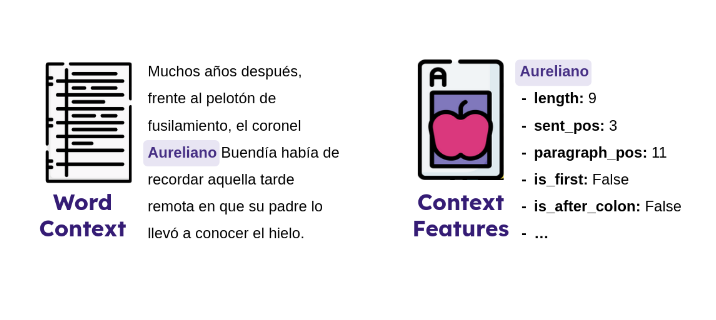

Los modelos de clasificación de palabra (o tokens en general) suelen apoyarse fuertemente en las características mofológicas y en los grafismos que componen las palabras. Es por ello por lo que para este tipo de modelos no representan numéricamente las palabras en base a embeddings sino a características del lenguaje

In [52]:
# Define a function to extract features for each word in a sentence

def preprocess(sentence, i):

    word = sentence[i]

    features = {

        'word': word,
        'is_first': i == 0, #if the word is a first word
        'is_last': i == len(sentence) - 1,  #if the word is a last word
        'is_capitalized': word[0].upper() == word[0],
        'is_all_caps': word.upper() == word,      #word is in uppercase
        'is_all_lower': word.lower() == word,      #word is in lowercase
         #prefix of the word
        'prefix-1': word[0],
        'prefix-2': word[:2],
        'prefix-3': word[:3],
         #suffix of the word
        'suffix-1': word[-1],
        'suffix-2': word[-2:],
        'suffix-3': word[-3:],
         #extracting previous word
        'prev_word': '' if i == 0 else sentence[i-1],
         #extracting next word
        'next_word': '' if i == len(sentence)-1 else sentence[i+1],
        'has_hyphen': '-' in word,    #if word has hypen
        'is_numeric': word.isdigit(),  #if word is in numeric
        'capitals_inside': word[1:].lower() != word[1:]
    }
    return features


preprocess(['Ángel', 'es', 'el', 'profe', 'guay'],0)

{'word': 'Ángel',
 'is_first': True,
 'is_last': False,
 'is_capitalized': True,
 'is_all_caps': False,
 'is_all_lower': False,
 'prefix-1': 'Á',
 'prefix-2': 'Án',
 'prefix-3': 'Áng',
 'suffix-1': 'l',
 'suffix-2': 'el',
 'suffix-3': 'gel',
 'prev_word': '',
 'next_word': 'es',
 'has_hyphen': False,
 'is_numeric': False,
 'capitals_inside': False}

Sin entrar mucho en detalle, es un tipo de algoritmo que se utiliza mucho para los problemas de clasificación de tokens


### Preprocesamiento

In [53]:
X = []

y = []

for sentence_annotated in corpus:
    sentence = [item[0] for item in sentence_annotated]
    annotation = [item[1] for item in sentence_annotated]

    X_sentence = [preprocess(sentence, i) for i in range(len(sentence))]
    y_sentence = annotation

    X.append(X_sentence)
    y.append(y_sentence)

In [ ]:
X_sentence[0:2]

[{'word': 'François',
  'is_first': True,
  'is_last': False,
  'is_capitalized': True,
  'is_all_caps': False,
  'is_all_lower': False,
  'prefix-1': 'F',
  'prefix-2': 'Fr',
  'prefix-3': 'Fra',
  'suffix-1': 's',
  'suffix-2': 'is',
  'suffix-3': 'ois',
  'prev_word': '',
  'next_word': 'reconoció',
  'has_hyphen': False,
  'is_numeric': False,
  'capitals_inside': False},
 {'word': 'reconoció',
  'is_first': False,
  'is_last': False,
  'is_capitalized': False,
  'is_all_caps': False,
  'is_all_lower': True,
  'prefix-1': 'r',
  'prefix-2': 're',
  'prefix-3': 'rec',
  'suffix-1': 'ó',
  'suffix-2': 'ió',
  'suffix-3': 'ció',
  'prev_word': 'François',
  'next_word': 'a',
  'has_hyphen': False,
  'is_numeric': False,
  'capitals_inside': False},
 {'word': 'a',
  'is_first': False,
  'is_last': False,
  'is_capitalized': False,
  'is_all_caps': False,
  'is_all_lower': True,
  'prefix-1': 'a',
  'prefix-2': 'a',
  'prefix-3': 'a',
  'suffix-1': 'a',
  'suffix-2': 'a',
  'suffix-3': 

**Features**: Estas son las variables que vamos a usar para que el modelo aprenda a predecir el Named Entity Recognition de cada palabra

In [54]:
import pandas as pd

pd.DataFrame(X[0][0:4])

,word,is_first,is_last,is_capitalized,is_all_caps,is_all_lower,prefix-1,prefix-2,prefix-3,suffix-1,suffix-2,suffix-3,prev_word,next_word,has_hyphen,is_numeric,capitals_inside
0,Tengo,True,False,True,False,False,T,Te,Ten,o,go,ngo,,39 años,False,False,False
1,39 años,False,False,True,False,True,3,39,39,s,os,ños,Tengo,",",False,False,False
2,",",False,False,True,True,True,",",",",",",",",",",",",39 años,pues,False,False,False
3,pues,False,False,False,False,True,p,pu,pue,s,es,ues,",",",",False,False,False


**Labels**: Las etiquetas del Named Entity Recognition de cada muestra del dataset para que el modelo las aprenda

In [55]:
import pandas as pd

pd.DataFrame(y[0][0:4])

,0
0,
1,DATES
2,
3,


## 2.3 - Modelo de clasificación

Para este caso vamos a usar un modelo conocido en el mundillo del Machine Learning del lenguaje: **Conditional Random Fields** (CRF)

### Entrenamiento

In [56]:
!pip install -q sklearn-crfsuite

from sklearn_crfsuite import CRF
from sklearn_crfsuite.metrics import flat_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn_crfsuite.metrics import flat_classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, shuffle=True)

crf = CRF(
    algorithm='lbfgs',
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True
)
crf.fit(X_train, y_train)

y_pred = crf.predict(X_test)

<br>

### Evaluación

In [57]:
print(flat_classification_report(y_test, y_pred))

               precision    recall  f1-score   support

                    0.95      0.99      0.97      1031
      ANIMALS       0.00      0.00      0.00         2
        BOOKS       0.00      0.00      0.00         1
        DATES       0.00      0.00      0.00         7
        FILMS       0.00      0.00      0.00         1
      OBJECTS       0.50      0.09      0.15        11
ORGANIZATIONS       0.00      0.00      0.00         1
       PEOPLE       0.43      0.43      0.43        14
       PLACES       1.00      0.22      0.36         9
        TOPIC       0.59      0.30      0.40        33

     accuracy                           0.94      1110
    macro avg       0.35      0.20      0.23      1110
 weighted avg       0.92      0.94      0.93      1110



/home/thinbaker/Workspace/Curso-de-IA-y-NLP/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/thinbaker/Workspace/Curso-de-IA-y-NLP/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/thinbaker/Workspace/Curso-de-IA-y-NLP/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

<br>

### Predicción

In [58]:
sentence = 'LeIA es un master de la Universidad Autónoma de Madrid'

word_features = [preprocess(sentence.split(),i) for i in range(len(sentence.split()))]

crf.predict_single(word_features)

['PEOPLE', '', '', '', '', '', '', '', '', 'PEOPLE']

<br>

### Caso Real:  Lázaro, Observatorio de neologismos

[Lázaro](https://www.observatoriolazaro.es/) es una página web que TODOS los días analizar textos de prensa escrita para detectar neologismos de diferentes tipos. Además también lo publica en twitter y bluesky

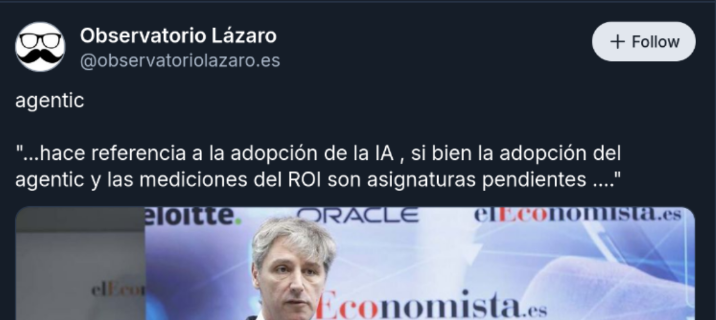

> **NOTA**: Lázaro utiliza un modelo de CRF para la detección de neologismos. Su código fuente está publicado y podéis verlo como un ejemplo real de proyecto de ML: https://github.com/lirondos/lazaro/blob/master/tests/rss_tests.py

<br>

---

## **2.4 - Modelos preconstruidos. Spacy**

En esta sección hemos visto cómo hacer sistemas de clasificación de documentos y de tokens. Este problema es tan común y muchas veces tan general (por ejemplo, la detección de noticias falsas o la clasificación POS de los tokens de una oración) que existen algoritmos preentenados que permiten tener que desarrollar nuestros propios algoritmos cada vez que tenemos que hacer un proyecto de este estilo. Uno de ellos es spacy

Spacy tiene diferentes modelos para diferentes idiomas. En el caso de español tiene 4 modelos entrenados con diferentes dataset. Los 4 tienen funcionalidades similares pero unos más que otros https://spacy.io/models/es

In [ ]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 74.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### **Token Classification**



In [59]:
import spacy
import pandas as pd
from spacy.lang.es.examples import sentences

corpus = df['text'].to_list()
nlp = spacy.load("es_core_news_sm")
doc = nlp(corpus[1])

data = []
for token in doc:
    data.append(
        {
            "token":token.text,
            "lemma":token.lemma_,
            "pos":token.pos_,
            "ner":token.ent_type_,
        }
    )

print(doc.text)
pd.DataFrame(data).head(10)

Cuando sales de casa, ya estás planeando que foto subir a Instagram en las stories para que él la vea, porque estas alturas ya tenéis bromitas internas, jijiji.


,token,lemma,pos,ner
0,Cuando,cuando,SCONJ,
1,sales,sal,NOUN,
2,de,de,ADP,
3,casa,casa,NOUN,
4,",",",",PUNCT,
5,ya,ya,ADV,
6,estás,estar,AUX,
7,planeando,planear,VERB,
8,que,que,SCONJ,
9,foto,foto,NOUN,


### Dependency graphs

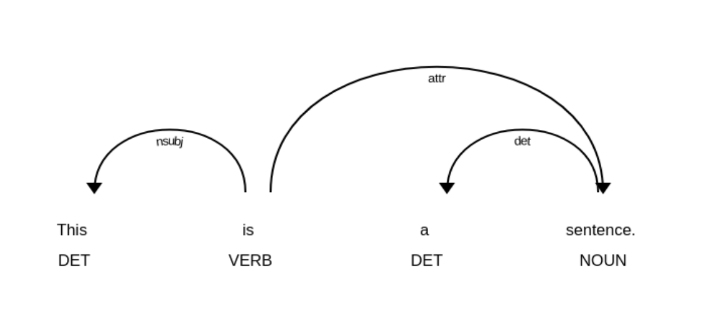

In [60]:
import spacy
import pandas as pd
from spacy.lang.es.examples import sentences

corpus = df['text'].to_list()
nlp = spacy.load("es_core_news_sm")
doc = nlp(corpus[1])

data = []
for token in doc:
    data.append(
        {
            "token":token.text,
            "dep":token.dep_,
        }
    )

pd.DataFrame(data)

,token,dep
0,Cuando,mark
1,sales,nsubj
2,de,case
3,casa,nmod
4,",",punct
5,ya,advmod
6,estás,aux
7,planeando,ROOT
8,que,mark
9,foto,ccomp


### Information Retrieval

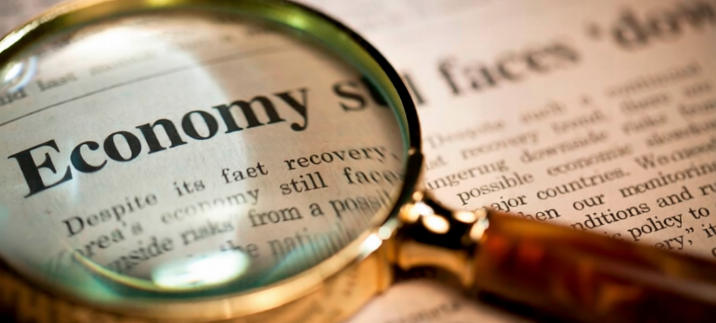

In [61]:
import spacy
from spacy.lang.es.examples import sentences

corpus = df['text'].to_list()
nlp = spacy.load("es_core_news_sm")

docs = [nlp(doc) for doc in corpus]

# Consulta de búsqueda
query = nlp("crisis económica")

similitudes = [(doc, doc.similarity(query)) for doc in docs]

# Ordenar los documentos por similitud, de mayor a menor
similitudes_ordenadas = sorted(similitudes, key=lambda x: x[1], reverse=True)

# Mostrar el documento más relevante
print(f"Texto: {similitudes_ordenadas[0][0].text}")
print(f"Similitud: {similitudes_ordenadas[0][1]:.4f}")

Texto: Cuando gobierne los peores y caiga la lluvia ácida y no haya electricidad, ¿tú qué sabes hacer, amiga?
Similitud: 0.4573


/tmp/ipykernel_17207/649729510.py:12: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  similitudes = [(doc, doc.similarity(query)) for doc in docs]


<br>

# **3 - Guardado de un modelo**

Hasta ahora hemos visto cómo cónfigurar, entrenar, evaluar y predecir con un modelo de Machine Learning. Sin embargo en la vida real no solo nos interesa usarlo dentro del contexto de un notebook, sino que nos interesa distribuirlo. Para ello es necesario guardarlo

Para poder distribuir un modelo entrenado, lo primero que necesitamos es poder guardarlo en un archivo. Este archivo debe contener el modelo junto con los "parámetros" calculados después del entrenamiento

## **3.1. Pickle**

Pickle es una librería de python que permite guardar variables en memoria a un archivo binario que posteriormente se pueden volver a cargar en memoria (algo similar a lo que hace Word cuando guardamos un archivo `.docx` para luego después volverlo a abrirlo). En el caso de pickle, la extensión del archivo es `.pkl`

### Guardado de datos

In [62]:
data = [
    {"Alumno":1, "Horas de estudio":7, "Nota":10.0},
    {"Alumno":2, "Horas de estudio":6, "Nota":8.5},
    {"Alumno":3, "Horas de estudio":1, "Nota":2.1},
    {"Alumno":4, "Horas de estudio":1.5,"Nota":3},
    {"Alumno":5, "Horas de estudio":8, "Nota":7.2},
    {"Alumno":6, "Horas de estudio":4, "Nota":6.4},
    {"Alumno":7, "Horas de estudio":3, "Nota":5.0},
    {"Alumno":8, "Horas de estudio":4, "Nota":5.7},
    {"Alumno":9, "Horas de estudio":6, "Nota":8.4},
    {"Alumno":10, "Horas de estudio":6, "Nota":9.2},
    {"Alumno":11, "Horas de estudio":6, "Nota":6.4},
    {"Alumno":12, "Horas de estudio":2, "Nota":4.},
    {"Alumno":13, "Horas de estudio":2, "Nota":3.},
    {"Alumno":14, "Horas de estudio":2, "Nota":5.7},
    {"Alumno":15, "Horas de estudio":5, "Nota":4.2},
    {"Alumno":16, "Horas de estudio":5, "Nota":6.4},
    {"Alumno":17, "Horas de estudio":6, "Nota":7.2},
    {"Alumno":18, "Horas de estudio":10, "Nota":8.5},
    {"Alumno":19, "Horas de estudio":1, "Nota":2.5},
    {"Alumno":20, "Horas de estudio":7, "Nota":7.6}
]

In [63]:
import pickle

# Guardar (Pickling)
with open('datos_alumnos.pkl', 'wb') as f:
    pickle.dump(data, f)

In [64]:
import os

os.listdir()

['corrector_noise_channel.ipynb',
 'nlp_ml_aprendizaje_supervisado.ipynb',
 'datos_alumnos.pkl']

In [65]:
import pickle

# Cargar (Unpickling)
with open('datos_alumnos.pkl', 'rb') as f:
    datos_recuperados = pickle.load(f)

print(datos_recuperados)

[{'Alumno': 1, 'Horas de estudio': 7, 'Nota': 10.0}, {'Alumno': 2, 'Horas de estudio': 6, 'Nota': 8.5}, {'Alumno': 3, 'Horas de estudio': 1, 'Nota': 2.1}, {'Alumno': 4, 'Horas de estudio': 1.5, 'Nota': 3}, {'Alumno': 5, 'Horas de estudio': 8, 'Nota': 7.2}, {'Alumno': 6, 'Horas de estudio': 4, 'Nota': 6.4}, {'Alumno': 7, 'Horas de estudio': 3, 'Nota': 5.0}, {'Alumno': 8, 'Horas de estudio': 4, 'Nota': 5.7}, {'Alumno': 9, 'Horas de estudio': 6, 'Nota': 8.4}, {'Alumno': 10, 'Horas de estudio': 6, 'Nota': 9.2}, {'Alumno': 11, 'Horas de estudio': 6, 'Nota': 6.4}, {'Alumno': 12, 'Horas de estudio': 2, 'Nota': 4.0}, {'Alumno': 13, 'Horas de estudio': 2, 'Nota': 3.0}, {'Alumno': 14, 'Horas de estudio': 2, 'Nota': 5.7}, {'Alumno': 15, 'Horas de estudio': 5, 'Nota': 4.2}, {'Alumno': 16, 'Horas de estudio': 5, 'Nota': 6.4}, {'Alumno': 17, 'Horas de estudio': 6, 'Nota': 7.2}, {'Alumno': 18, 'Horas de estudio': 10, 'Nota': 8.5}, {'Alumno': 19, 'Horas de estudio': 1, 'Nota': 2.5}, {'Alumno': 20, 'Ho

### Guardado de funciones

Lo bueno de pickle es que no solo podemos guardar estructuras de datos, sino que podemos guardar variables de python en general, como por ejemplo funciones

In [66]:
import pickle

# 1. Definimos una función estándar
def saludar(nombre):
    return f"Hola! Me llamo {nombre}"

# 2. Guardamos la función en un archivo
with open('mi_funcion.pkl', 'wb') as f:
    pickle.dump(saludar, f)

print("Función guardada")

Función guardada


In [ ]:
# 3. Cargamos la función
with open('mi_funcion.pkl', 'rb') as f:
    funcion_recuperada = pickle.load(f)

# 4. La usamos normalmente
resultado = funcion_recuperada("Ángel")
print(resultado)

Hola! Me llamo Ángel


### Guardado de modelos

En último término, un modelo de Sklearn no es más que un conjunto de funciones (`train`, `predict`...) con unos parámetros aprendidos durante el entrenamiento. Por tanto también podemos usar pickle pra guardarlo

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

data = pd.DataFrame([
    {"Alumno":1, "Horas de estudio":7, "Nota":10.0},
    {"Alumno":2, "Horas de estudio":6, "Nota":8.5},
    {"Alumno":3, "Horas de estudio":1, "Nota":2.1},
    {"Alumno":4, "Horas de estudio":1.5,"Nota":3},
    {"Alumno":5, "Horas de estudio":8, "Nota":7.2},
    {"Alumno":6, "Horas de estudio":4, "Nota":6.4},
    {"Alumno":7, "Horas de estudio":3, "Nota":5.0},
    {"Alumno":8, "Horas de estudio":4, "Nota":5.7},
    {"Alumno":9, "Horas de estudio":6, "Nota":8.4},
    {"Alumno":10, "Horas de estudio":6, "Nota":9.2},
    {"Alumno":11, "Horas de estudio":6, "Nota":6.4},
    {"Alumno":12, "Horas de estudio":2, "Nota":4.},
    {"Alumno":13, "Horas de estudio":2, "Nota":3.},
    {"Alumno":14, "Horas de estudio":2, "Nota":5.7},
    {"Alumno":15, "Horas de estudio":5, "Nota":4.2},
    {"Alumno":16, "Horas de estudio":5, "Nota":6.4},
    {"Alumno":17, "Horas de estudio":6, "Nota":7.2},
    {"Alumno":18, "Horas de estudio":10, "Nota":8.5},
    {"Alumno":19, "Horas de estudio":1, "Nota":2.5},
    {"Alumno":20, "Horas de estudio":7, "Nota":7.6}
])

X = data[["Horas de estudio"]]
y = data["Nota"]

model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [ ]:
import pickle

with open('mi_modelo.pkl', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
# 3. Cargamos la función
with open('mi_modelo.pkl', 'rb') as f:
    modelo_cargado = pickle.load(f)

# 4. Nuevo dato de alumno
datos_alumno = pd.DataFrame({"Horas de estudio": [3]})

# 5. La usamos normalmente
nota_predicha = modelo_cargado.predict(datos_alumno)
print(nota_predicha)

[4.77509007]


> **NOTA**: No todos los modelos de Machine Learning se guardan con pickle. Por ejemplo las redes neuronales se suelen guardar con otro tipo de formatos (protobuffer, h5,...).

## **3.2. - Pipeline**

### Fake News Dataset

In [ ]:
import pandas as pd

# Datos
df = pd.read_csv("hf://datasets/mariagrandury/fake_news_corpus_spanish/test.csv")
df

,ID,CATEGORY,TOPICS,SOURCE,HEADLINE,TEXT,LINK
0,1,True,Covid-19,El Economista,Covid-19: mentiras que matan,El control de la Covid-19 no es sólo un tema d...,https://www.eleconomista.com.mx/opinion/Covid-...
1,2,False,Política,El matinal,El Gobierno podrá acceder a las IPs de los móv...,El Gobierno de Pedro Sánchez y Pablo Iglesias ...,https://www.elmatinal.com/espana-ultima-hora/e...
2,3,True,Política,El País,La comunidad musulmana catalana denuncia a Vox...,Las tres federaciones que agrupan al 90% de la...,https://elpais.com/espana/elecciones-catalanas...
3,4,False,Política,AFPFactual,NaN,Se han dado a conocer los datos electorales pr...,https://perma.cc/GYE6-SPMB
4,5,True,Sociedad,La Republica,El censo poblacional 2018 tendrá un costo de $...,La primera fase del censo será virtual y solo ...,https://www.larepublica.co/economia/el-censo-p...
...,...,...,...,...,...,...,...
567,568,True,Covid-19,El Financiero,Encuentran nueva variante de COVID en México: ...,El Instituto de Diagnóstico y Referencia Epide...,https://www.elfinanciero.com.mx/salud/encuentr...
568,569,False,Sociedad,diariogol,El móvil de más de 60.000 euros de la princesa...,La hija del rey Felipe y de la reina Letizia y...,https://www.diariogol.com/gossip/el-movil-de-m...
569,570,False,Política,AFPFactual,NaN,"Evidentemente, Barak Obama ha sido arrestado e...","Perma | Obama, Biden y la directora de la CIA,..."
570,571,True,Covid-19,Redacción Médica,Covid: las vacunas puestas en España no alcanz...,El Ministerio de Sanidad ha actualizado los da...,https://www.redaccionmedica.com/secciones/sani...


In [ ]:
corpus = df['TEXT'].to_list()
labels = df['TOPICS'].to_list()

### **Modelo Complejo**

En proyectos reales un modelo de machine learning es más que únicamente un modelo entrenado. También tenemos que hacer otros pasos como procesar, tokenizar y vectorizar datos

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


# Vectorizador
vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer='word',
    ngram_range=(1, 3),
    max_features=1200,
)

# Reducción de dimensionalidad
dim_reducer = TruncatedSVD(
    n_components=200,
    random_state=42,
)

# Modelo
model = SVC()


# vectorizamos
X = vectorizer.fit_transform(corpus)

# Reducimos dimensionalidad
X = dim_reducer.fit_transform(X)
y = labels


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Entrenamos el modelo
model.fit(X_train,y_train)

SVC()

En este tipo de modelos guardar un pickle del modelo no es suficiente porque nos perderíamos toda la información de cómo vectorizarlo

<br>

### Pipeline de Sklearn

Para poder resolver el problema anterior Sklearn permite crear pipelines. Un pipeline es una concatenación de pasos disjuntos pero conceptutalmente dependientes. El hecho de concatenarlos nos permite guardar diferentes partes del modelo en una misma variable.

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

pipe = Pipeline(
    [
        (
            'vectorizer',
            TfidfVectorizer(
                lowercase=True,
                analyzer='word',
                ngram_range=(1, 3),
                max_features=1200,
            )
        ),
        (
            'dim_reduction',
            TruncatedSVD(
                n_components=200,
                random_state=42,
            ),
        ),
        (
            "model",
            SVC(),
        )
    ])
pipe.fit(corpus,labels)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(max_features=1200, ngram_range=(1, 3))),
                ('dim_reduction',
                 TruncatedSVD(n_components=200, random_state=42)),
                ('model', SVC())])

Ahora que tenemos todo en una sola variable ya podemos guardarlo sin problemas

In [ ]:
import pickle

with open('topic_classification_model.pkl', 'wb') as f:
    pickle.dump(pipe, f)

In [ ]:
# 3. Cargamos la función
with open('topic_classification_model.pkl', 'rb') as f:
    topic_classification_model = pickle.load(f)

# 4. Nuevo dato de alumno
nuevo_documento = "El Gobierno acusado por un nuevo caso de corrupción"

pred = topic_classification_model.predict([nuevo_documento])
print(pred)

['Sociedad']


> **NOTA**: Aunque el problema de poder guardar un modelo junto con la lógica de preprocesamiento es un problema común a todos los tipos de ML, no todas las librerías de ML lo resuelven igual. En el caso de Sklearn, la solución son los pipelines pero otro tipo de librerías tienen otro tipo de soluciones

# Ejercicio - SpellChecker

Una de las primeras aplicaciones de los modelos de IA en problemas de lenguaje (además de los clasificadores de spam) los modelos fueron los correctores ortotipográficos. Existen diferentes formas de atacar ese problema (IA tradicional, Machine Learning, Deep Learning...).

Desde la perspectiva del Machine learning supervisado necesitaríamos un dataset (o corpus) de palabras con errores y su correspondiente palabra correcta como target. Por ejemplo, podríamos generar el siguiente corpus de palabras a partir de 100 años de soledad

In [68]:
import re
import requests


url = "https://gist.githubusercontent.com/ismaproco/6781d297ee65c6a707cd3c901e87ec56/raw/20d3520cd7c53d99215845375b1dca16ac827bd7/gabriel_garcia_marquez_cien_annos_soledad.txt"
text = requests.get(url).text.lower()  # Convertimos a minúsculas

# Tokenizamos palabras (solo a-z)
words = re.findall(r'\b[a-záéíóúñü]+\b', text)

# Quitamos duplicados para tener vocabulario
vocab = list(set(words))
print("Número de palabras únicas en el vocabulario:", len(vocab))

Número de palabras únicas en el vocabulario: 15692


In [69]:
print(words[0:30])

['gabriel', 'garcía', 'márquez', 'cien', 'años', 'de', 'soledad', 'editado', 'por', 'ediciones', 'la', 'cueva', 'para', 'j', 'omi', 'garcía', 'ascot', 'y', 'maría', 'luisa', 'elio', 'cien', 'años', 'de', 'soledad', 'gabriel', 'garcía', 'márquez', 'muchos', 'años']


## Canal de Ruido

A partir del lenguaje natural podemos obtener palabras, pero cuesta mucho buscar/generar errores manualmente. Para este problema en el NLP se usaba una técnica que se denomina "canal de ruido" Que permite generar un dataset artificial a partir de una función que genera errores

In [ ]:
import numpy as np

# Mapa simple QWERTY (fila, columna)
keyboard = {
    'q': (0,0), 'w': (0,1), 'e': (0,2), 'r': (0,3), 't': (0,4), 'y': (0,5), 'u': (0,6), 'i': (0,7), 'o': (0,8), 'p': (0,9),
    'a': (1,0), 's': (1,1), 'd': (1,2), 'f': (1,3), 'g': (1,4), 'h': (1,5), 'j': (1,6), 'k': (1,7), 'l': (1,8), 'ñ': (1,9),  "'" : (1,10),
    'z': (2,0), 'x': (2,1), 'c': (2,2), 'v': (2,3), 'b': (2,4), 'n': (2,5), 'm': (2,6)
}

> **NOTA**: Usamos esta forma de "vectorizar" los caracteres (sin tokenizar y vectorizar como hemos visto antes) porque es conveniente para representar las letras en un teclado. Desde una perspectiva mecánica, las "features" de una letra en el teclado es su posición en términos de fila y columna

In [ ]:
import random

def generate_typo(word, error_prob=0.1):

    # Elegimos aleatoriamente la posición del error
    pos = random.randint(0, len(word)-1)

    # obtener posición
    x, y = keyboard[word[pos]]

    # letras cercanas
    neighbors = [c for c in keyboard if (keyboard[c][0] in [x-1,x+1]) and (keyboard[c][1] in [y-1,y+1])]

    # Elegir una letra
    wrong_character = random.choice(neighbors)

    # Reemplazamos el caracter en la posición elegida
    word = word[:pos] + wrong_character + word[pos+1:]

    return word

In [ ]:
generate_typo('hola')

'holw'

El objetivo de este ejercicio es usar la función `generate_typo` para hacer un modelo de aprendizaje supervisado que aprenda a corregir errores